In [2]:
import os
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import pearsonr
from tqdm import tqdm
import time
from collections import Counter
from matplotlib.patches import Patch
from scipy.spatial.distance import cdist
import re
import scipy
import warnings

from scipy.stats import zscore
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, fcluster
from collections import defaultdict
from cuml.metrics import pairwise_distances

import rmm
import cupy
import cudf
import cupy as cp
import cvxpy as cpv
from rmm.allocators.cupy import rmm_cupy_allocator
from sklearn.feature_extraction.text import CountVectorizer
from cuml.linear_model import ElasticNet
import anndata as an
import scanpy as sc
from scanpy.tools._utils import get_init_pos_from_paga 
import rapids_singlecell as rsc
import scvi

import torch
# from torchnmf.nmf import NMF

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

# Load Gene Metadata

In [3]:
%%time
fpath = "../../resources/gene_names.tsv.gz"
gdf = pd.read_csv(fpath, sep='\t', low_memory=False)
print(f"{gdf.shape=}")

protein_coding = gdf[gdf['Gene type'] == 'protein_coding']['Gene name'].unique()
print(f"N protein coding: {protein_coding.shape=}")

gdf.shape=(73466, 8)
N protein coding: protein_coding.shape=(18149,)
CPU times: user 129 ms, sys: 15.8 ms, total: 145 ms
Wall time: 152 ms


# Load our data

In [4]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
adata = sc.read_h5ad(fpath)
adata = adata[:, adata.var_names.isin(protein_coding)].copy()
adata.X = adata.layers['raw_counts'].copy()

# define new annotation columns
cluster_map = {
    'C2' : 'C2',
    'C3' : 'C3',
    'C4' : 'Control',
    'C5' : 'Control',
}

adata.obs['cell_type'] = adata.obs['cluster_str'].map(cluster_map)
adata = adata[adata.obs['cell_type'].notna(), :].copy()

# aggregrate
agg = 'sum'
adata = sc.get.aggregate(
    adata,
    by='cell_type',
    func=agg,
)

adata.X = adata.layers[agg]
rsc.get.anndata_to_GPU(adata)
rsc.pp.normalize_total(adata, target_sum=1e4)
rsc.pp.log1p(adata)
adata.layers['log_norm'] = adata.X.copy()
rsc.pp.normalize_total(adata, target_sum=1)
adata.layers['probs'] = adata.X.copy()
rsc.get.anndata_to_CPU(adata)

adata

CPU times: user 2.64 s, sys: 4.68 s, total: 7.33 s
Wall time: 11 s


AnnData object with n_obs × n_vars = 3 × 13452
    obs: 'cell_type'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_id'
    uns: 'log1p'
    layers: 'sum', 'log_norm', 'probs'

# Load other datasets

In [5]:
datasets = {
    'Gomes 2018' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/gomes_2018/gomes.h5ad",
        'annotation_column' : 'cell_type',
        'layer' : 'raw_counts',
    },
    'Pellin 2019' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/pellin_2019/pellin.anndata.h5ad",
        'annotation_column' : 'dataset',
        'layer' : 'raw_counts',
    },
    'Georgolopoulos 2021' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/georgolopoulos_2021/anndata.h5ad",
        'annotation_column' : 'populations',
        'layer' : 'matrix',
    },
    'Weng 2024' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/weng_2024/scanpy_objects/young1_all_t2.h5ad",
        'annotation_column' : 'STD.CellType',
        'layer' : 'raw_counts',
    },

    'Ng 2024' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/ng_2024/iHSC.h5ad",
        'annotation_column' : 'celltype',
        'layer' : None,
    },
    'Setty 2019' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/setty_2019/anndata.h5ad",
        'annotation_column' : 'cell_type',
        'layer' : 'raw_counts',
    },
}

In [6]:
%%time

data = {
    'Our data' : adata.copy()
}

for dataset, params in datasets.items():
    print(f"\n--- Loading dataset: {dataset} ---")
    t0 = time.time()

    fpath = params['file_path']
    column = params['annotation_column']
    layer = params['layer']

    print(f"\t - Reading file: {fpath}")
    bdata = sc.read_h5ad(fpath)
    bdata.var_names_make_unique()
    print(f"\t - Read complete. Shape: {bdata.shape}")

    # Annotate cell type and filter
    bdata.obs['cell_type'] = bdata.obs[column].copy()
    n_total = bdata.shape[0]
    bdata = bdata[bdata.obs['cell_type'].notna(), :].copy()
    n_filtered = bdata.shape[0]
    print(f"\t - Cells before filtering: {n_total}, after filtering: {n_filtered}")

    # Select layer if specified
    if layer is not None:
        print(f"\t - Using layer: {layer}")
        bdata.X = bdata.layers[layer].copy()
    else:
        print("\t - Using .X as is (no layer specified)")

    bdata = bdata[:, bdata.var_names.isin(protein_coding)].copy()
    bdata.X = bdata.X.astype('float32')
    rsc.get.anndata_to_GPU(bdata)
    rsc.pp.filter_genes(bdata, min_counts=10)
    
    print(f"\t - Filtered genes. Final Shape: {bdata.shape}")

    n_genes = bdata.shape[1]
    n_cell_types = bdata.obs['cell_type'].nunique()
    cell_types = sorted(bdata.obs['cell_type'].unique())
    print(f"\t - Unique cell types ({n_cell_types}): {cell_types[:5]}{' ...' if n_cell_types > 5 else ''}")

    t1 = time.time()
    print(f"\t - Time to load and process: {t1 - t0:.2f} seconds")

    # aggregate
    rsc.get.anndata_to_CPU(bdata)
    agg = 'sum'
    bdata = sc.get.aggregate(
        bdata,
        by='cell_type',
        func=agg,
    )
    
    bdata.X = bdata.layers[agg]
    rsc.get.anndata_to_GPU(bdata)
    rsc.pp.normalize_total(bdata, target_sum=1e4)
    rsc.pp.log1p(bdata)
    bdata.layers['log_norm'] = bdata.X.copy()
    rsc.pp.normalize_total(bdata, target_sum=1)
    bdata.layers['probs'] = bdata.X.copy()
    rsc.get.anndata_to_CPU(bdata)

    data[dataset] = bdata.copy()

print('done')


--- Loading dataset: Gomes 2018 ---
	 - Reading file: /nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/gomes_2018/gomes.h5ad


/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


	 - Read complete. Shape: (286, 56269)
	 - Cells before filtering: 286, after filtering: 286
	 - Using layer: raw_counts
filtered out 3550 genes that are detected in less than 10 counts
	 - Filtered genes. Final Shape: (286, 13492)
	 - Unique cell types (5): ['DAY15', 'DAY2', 'DAY25', 'HDF', 'UCB']
	 - Time to load and process: 1.26 seconds

--- Loading dataset: Pellin 2019 ---
	 - Reading file: /nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/pellin_2019/pellin.anndata.h5ad
	 - Read complete. Shape: (21412, 20582)
	 - Cells before filtering: 21412, after filtering: 21412
	 - Using layer: raw_counts
filtered out 2475 genes that are detected in less than 10 counts
	 - Filtered genes. Final Shape: (21412, 13979)
	 - Unique cell types (11): ['CMP', 'GMP', 'HSC', 'LinNegCD34NegCD164high', 'LinNegCD34NegCD164low'] ...
	 - Time to load and process: 40.01 seconds

--- Loading dataset: Georgolopoulos 2021 ---
	 - Reading file: /nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/

/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


	 - Read complete. Shape: (53511, 36601)
	 - Cells before filtering: 53511, after filtering: 53511
	 - Using layer: matrix
filtered out 4050 genes that are detected in less than 10 counts
	 - Filtered genes. Final Shape: (53511, 13384)
	 - Unique cell types (7): ['Ery1', 'Ery2', 'HSPC', 'MPP1', 'MPP2'] ...
	 - Time to load and process: 37.77 seconds

--- Loading dataset: Weng 2024 ---
	 - Reading file: /nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/weng_2024/scanpy_objects/young1_all_t2.h5ad
	 - Read complete. Shape: (25442, 36601)
	 - Cells before filtering: 25442, after filtering: 25252
	 - Using layer: raw_counts
filtered out 3255 genes that are detected in less than 10 counts
	 - Filtered genes. Final Shape: (25252, 14179)
	 - Unique cell types (20): ['B', 'CD4', 'CD8', 'CLP', 'CMP'] ...
	 - Time to load and process: 7.58 seconds

--- Loading dataset: Ng 2024 ---
	 - Reading file: /nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/ng_2024/iHSC.h5ad
	 - Read comple

# Merge into a single object

In [7]:
%%time
adatas = [v for v in data.values()]
keys = [k for k in data.keys()]

# Concatenate into one AnnData object, with a new column in .obs named 'batch'
adata = sc.concat(adatas, join="outer", label="batch", keys=keys)
adata

CPU times: user 343 ms, sys: 30.2 ms, total: 374 ms
Wall time: 419 ms


/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 74 × 16530
    obs: 'cell_type', 'batch'
    layers: 'sum', 'log_norm', 'probs'

# Metadata Clean up

In [8]:
label_map = {
    # Experimental / Condition Labels
    'C2': '5TF (C2)',
    'C3': '5TF (C3)',
    'DAY2': '3TF (Day 2)',
    'DAY15': '3TF (Day 15)',
    'DAY25': '3TF (Day 25)',
    'Control': 'Control',
    'HDF': 'HDF',
    'UCB': 'UCB',

    # Hematopoietic Stem and Progenitor Cells (HSPCs)
    'HSC': 'HSC',
    'Refined.HSC': 'HSC',
    'hematopoietic stem cell': 'HSC',
    'HSPC': 'HSPC',
    'HSPC1': 'HSPC',
    'HSPC2': 'HSPC',
    'HSPC3': 'HSPC',
    'MPP': 'MPP',
    'MPP1': 'MPP',
    'MPP2': 'MPP',
    'LMPP': 'MPP',
    'hematopoietic multipotent progenitor': 'MPP',
    'CLP': 'CLP',
    'common lymphoid progenitor': 'CLP',
    'CMP': 'CMP',
    'GMP': 'GMP',
    'MEP': 'MEP',
    'MLP': 'MLP',
    'MDP': 'MDP',
    'dendtritic progenitor': 'DCP',
    'EryP': 'EryP',
    'erythroid progenitor': 'EryP',
    'MKP': 'MKP',
    'megakaryocyte progenitor': 'MKP',
    'MonoP': 'MonoP',
    'Mye Pro1': 'MonoP',
    'Mye Pro2': 'MonoP',
    'monocyte progenitor': 'MonoP',
    'myeloid progenitor': 'MyP',
    'EMK Pro1': 'EMKP',
    'EMK Pro2': 'EMKP',
    'PreBNK': 'PreBNK',
    'ProB': 'ProB',

    # Mature and Differentiated Cell Types
    'Ery1': 'Ery',
    'Ery2': 'Ery',
    'Mk1': 'MK',
    'Mk2': 'MK',
    'Mega': 'MK',
    'Mono': 'Mono',
    'Gran': 'Gran',
    'Eos': 'Eos',
    'B': 'B',
    'Plasma': 'Plasma',
    'NK': 'NK',
    'CD4': 'CD4',
    'CD8': 'CD8',
    'cDC': 'cDC',
    'pDC': 'pDC',
    
    # Lineage Negative Population
    'LinNegCD34NegCD164high': 'LinNeg',
    'LinNegCD34NegCD164low': 'LinNeg',
    'LinNegCD34PosCD164Pos': 'LinNeg',
    'LinNegCD34lowCD164high': 'LinNeg',

    # Stromal and Endothelial Cells
    'Strom1': 'Endo/Stromal',
    'Strom2': 'Endo/Stromal',
    'Strom3': 'Endo/Stromal',
    'Strom4': 'Endo/Stromal',
    'Venous': 'Endo/Stromal',
    'Endo': 'Endo',
    'Art1': 'Art',
    'Art2': 'Art',
    'Hemogenic': 'Hemogenic',
}

adata.obs['label'] = adata.obs['cell_type'].map(label_map)
adata.obs['label'].value_counts().head(10)

label
MPP             6
Endo/Stromal    5
HSC             4
HSPC            4
LinNeg          4
MK              3
MonoP           3
Ery             2
GMP             2
CMP             2
Name: count, dtype: int64

In [9]:
adata.obs.head()

,cell_type,batch,label
C2,C2,Our data,5TF (C2)
C3,C3,Our data,5TF (C3)
Control,Control,Our data,Control
DAY2,DAY2,Gomes 2018,3TF (Day 2)
DAY15,DAY15,Gomes 2018,3TF (Day 15)


In [10]:
adata.obs['group'] = np.where(adata.obs['cell_type'].isin(['C2', 'C3', 'Control']), 'data', 'atlas')
print(adata.obs['group'].value_counts().to_string())

group
atlas    71
data      3


# Filtering

In [11]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.filter_genes(adata, min_counts=0)

adata.X = adata.layers['log_norm'].copy()
adata

/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 74 × 16530
    obs: 'cell_type', 'batch', 'label', 'group'
    var: 'n_counts', 'n_cells'
    layers: 'sum', 'log_norm', 'probs'

In [12]:
# handle NaN
has_nan = np.isnan(adata.X).any()
print("Contains NaNs:", has_nan)

if scipy.sparse.issparse(adata.X):
    adata.X.data[np.isnan(adata.X.data)] = 0
else:
    adata.X[np.isnan(adata.X)] = 0

has_nan = np.isnan(adata.X).any()
print("Contains NaNs:", has_nan)

Contains NaNs: True
Contains NaNs: False


In [13]:
adata.obs.head()

,cell_type,batch,label,group
C2,C2,Our data,5TF (C2),data
C3,C3,Our data,5TF (C3),data
Control,Control,Our data,Control,data
DAY2,DAY2,Gomes 2018,3TF (Day 2),atlas
DAY15,DAY15,Gomes 2018,3TF (Day 15),atlas


In [15]:
adata

AnnData object with n_obs × n_vars = 74 × 16530
    obs: 'cell_type', 'batch', 'label', 'group'
    var: 'n_counts', 'n_cells'
    layers: 'sum', 'log_norm', 'probs'

In [17]:
%%time

rsc.get.anndata_to_CPU(adata)

regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs.head()

CPU times: user 51.9 ms, sys: 1.78 ms, total: 53.7 ms
Wall time: 60.1 ms


,cell_type,batch,label,group,S_score,G2M_score,phase
C2,C2,Our data,5TF (C2),data,-0.228243,-0.163221,G1
C3,C3,Our data,5TF (C3),data,-0.251723,-0.277109,G1
Control,Control,Our data,Control,data,-0.042851,0.380087,G2M
DAY2,DAY2,Gomes 2018,3TF (Day 2),atlas,-0.235165,-0.078370,G1
DAY15,DAY15,Gomes 2018,3TF (Day 15),atlas,-0.202471,-0.104844,G1


# Gene Filtering

In [18]:
# Set the column name in obs that encodes batch information
batch_col = 'batch'

# Get all unique batches
batches = adata.obs[batch_col].unique()

# Initialize presence matrix: rows = batches, columns = genes
gene_presence = []

for i, batch in enumerate(batches):
    mask = adata.obs[batch_col] == batch
    X = adata[mask].X
    if hasattr(X, "get"):
        X = X.get()
    if hasattr(X, "toarray"):
        X = X.toarray()
    # Genes present in this batch
    present = (X > 0).any(axis=0)
    gene_presence.append(present)
    print(f"Batch {i+1}/{len(batches)}: '{batch}' has {present.sum()} genes expressed")

gene_presence = np.vstack(gene_presence)
only_one_batch = gene_presence.sum(axis=0) == 1
genes_single_batch = adata.var_names[only_one_batch]

print("-" * 60)
print(f"Genes expressed in only one batch: {only_one_batch.sum()}")
print(f"Fraction of total genes: {only_one_batch.sum() / len(adata.var_names):.2%}")

Batch 1/7: 'Our data' has 13452 genes expressed
Batch 2/7: 'Gomes 2018' has 13492 genes expressed
Batch 3/7: 'Pellin 2019' has 13979 genes expressed
Batch 4/7: 'Georgolopoulos 2021' has 13384 genes expressed
Batch 5/7: 'Weng 2024' has 14179 genes expressed
Batch 6/7: 'Ng 2024' has 15023 genes expressed
Batch 7/7: 'Setty 2019' has 10438 genes expressed
------------------------------------------------------------
Genes expressed in only one batch: 1099
Fraction of total genes: 6.65%


In [19]:
adata.var['filter_pass'] = True # set the gene filter

# disallow genes only expressed in our data
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes_single_batch), False, adata.var['filter_pass'])

# disallow GO cell cycle genes
fpath = "../../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# disallow Regev cell cycle genes
fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
genes = [x.strip() for x in open(fpath)]
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

print(adata.var['filter_pass'].value_counts().to_string())

filter_pass
True     15022
False     1508


# scvi

/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/rapids_singlecell/preprocessing/_hvg.py:549: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
GPU available: True (cuda), used: True
TPU av

Training:   0%|          | 0/500 [00:00<?, ?it/s]

/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_K

Monitored metric elbo_validation did not improve in the last 10 records. Best score: 1773.185. Signaling Trainer to stop.


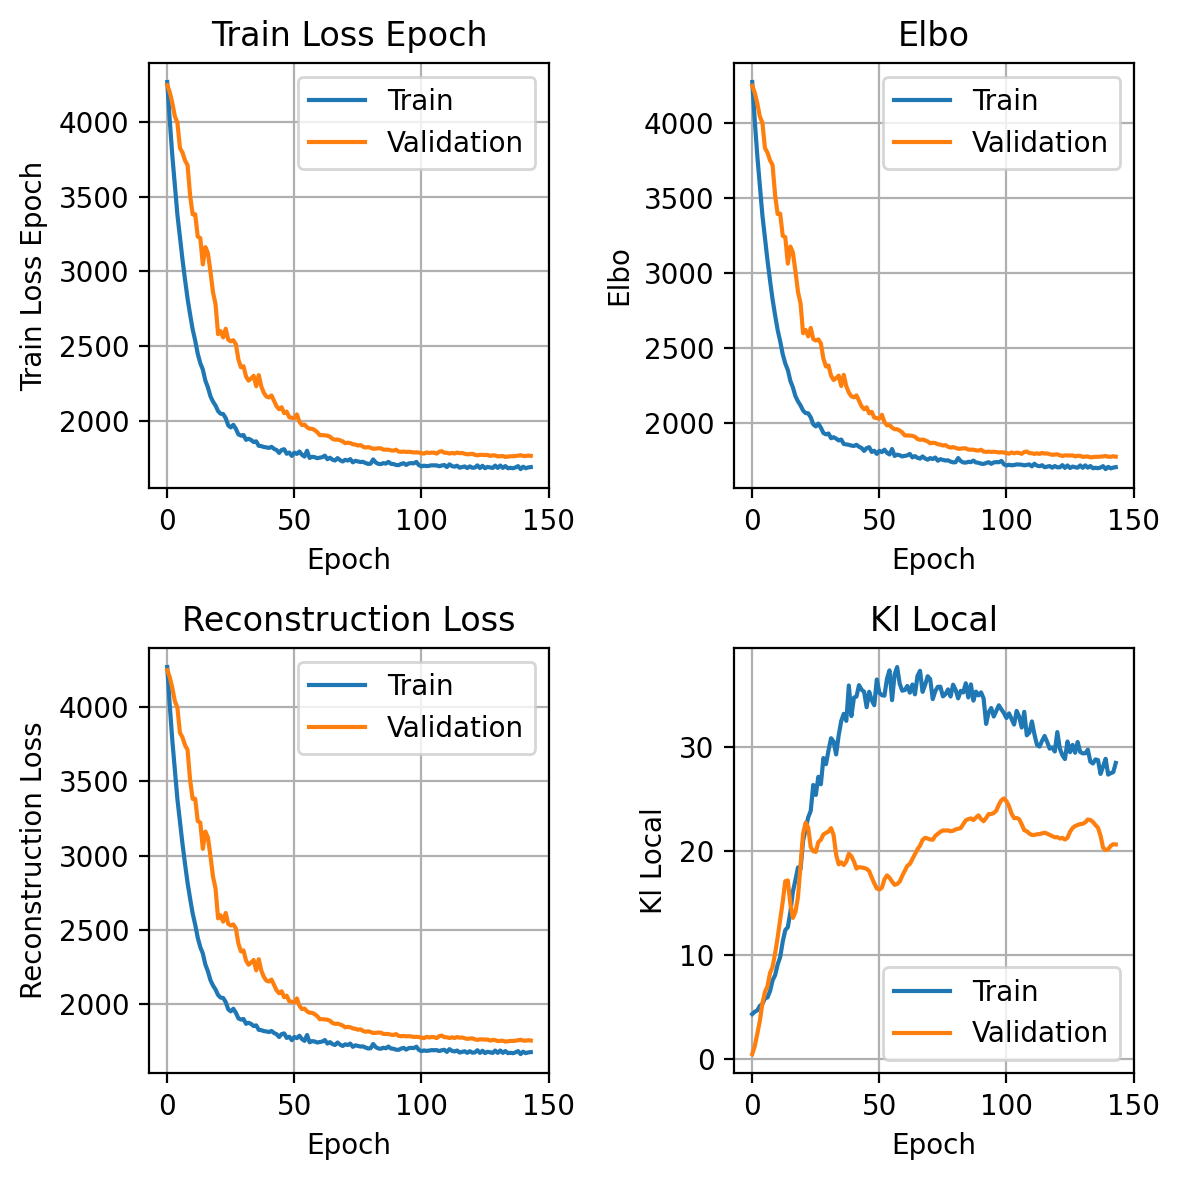

CPU times: user 6.79 s, sys: 302 ms, total: 7.09 s
Wall time: 7.88 s


In [20]:
%%time
batch_key = "batch"

rsc.get.anndata_to_CPU(adata)
bdata = adata.copy()
bdata = bdata[:, bdata.var['filter_pass']].copy()

rsc.get.anndata_to_GPU(bdata)
rsc.pp.highly_variable_genes(
    bdata,
    flavor="seurat_v3",
    n_top_genes=2500,
    batch_key=batch_key,
)

bdata = bdata[:, bdata.var['highly_variable']].copy()
rsc.get.anndata_to_CPU(bdata)

# scvi
scvi.model.SCVI.setup_anndata(
    bdata, 
    batch_key=batch_key,
    continuous_covariate_keys=['S_score', 'G2M_score'],
)

model = scvi.model.SCVI(
    bdata,
    n_hidden=128,
    n_latent=24,
    n_layers=2, 
    dropout_rate=0.25,
    dispersion='gene-cell',
    gene_likelihood='zinb',
)

model.train(
    max_epochs=500,
    accelerator='gpu',
    early_stopping_patience=10,
    early_stopping=True,
    batch_size=25,
    train_size=0.9,
    plan_kwargs={"lr": 1e-3},
)

history = model.history

metrics = [
    ("train_loss_epoch", "validation_loss"),
    ("elbo_train", "elbo_validation"),
    ("reconstruction_loss_train", "reconstruction_loss_validation"),
    ("kl_local_train", "kl_local_validation"),
]

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (train_key, val_key) in enumerate(metrics):
    ax = axes[i]
    train_df = history[train_key]
    val_df = history[val_key]

    ax.plot(train_df.index, train_df[train_key], label='Train')
    ax.plot(val_df.index, val_df[val_key], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(train_key.replace('_train', '').replace('_', ' ').title())
    ax.set_title(train_key.replace('_train', '').replace('_', ' ').title())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


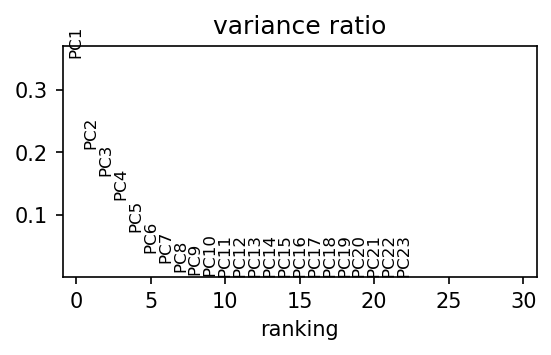

CPU times: user 125 ms, sys: 34.3 ms, total: 159 ms
Wall time: 171 ms


In [21]:
%%time 

embed = model.get_latent_representation()
embed = sc.AnnData(embed, obs=adata.obs)

rsc.get.anndata_to_GPU(embed)
rsc.pp.pca(embed)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2
sc.pl.pca_variance_ratio(embed)

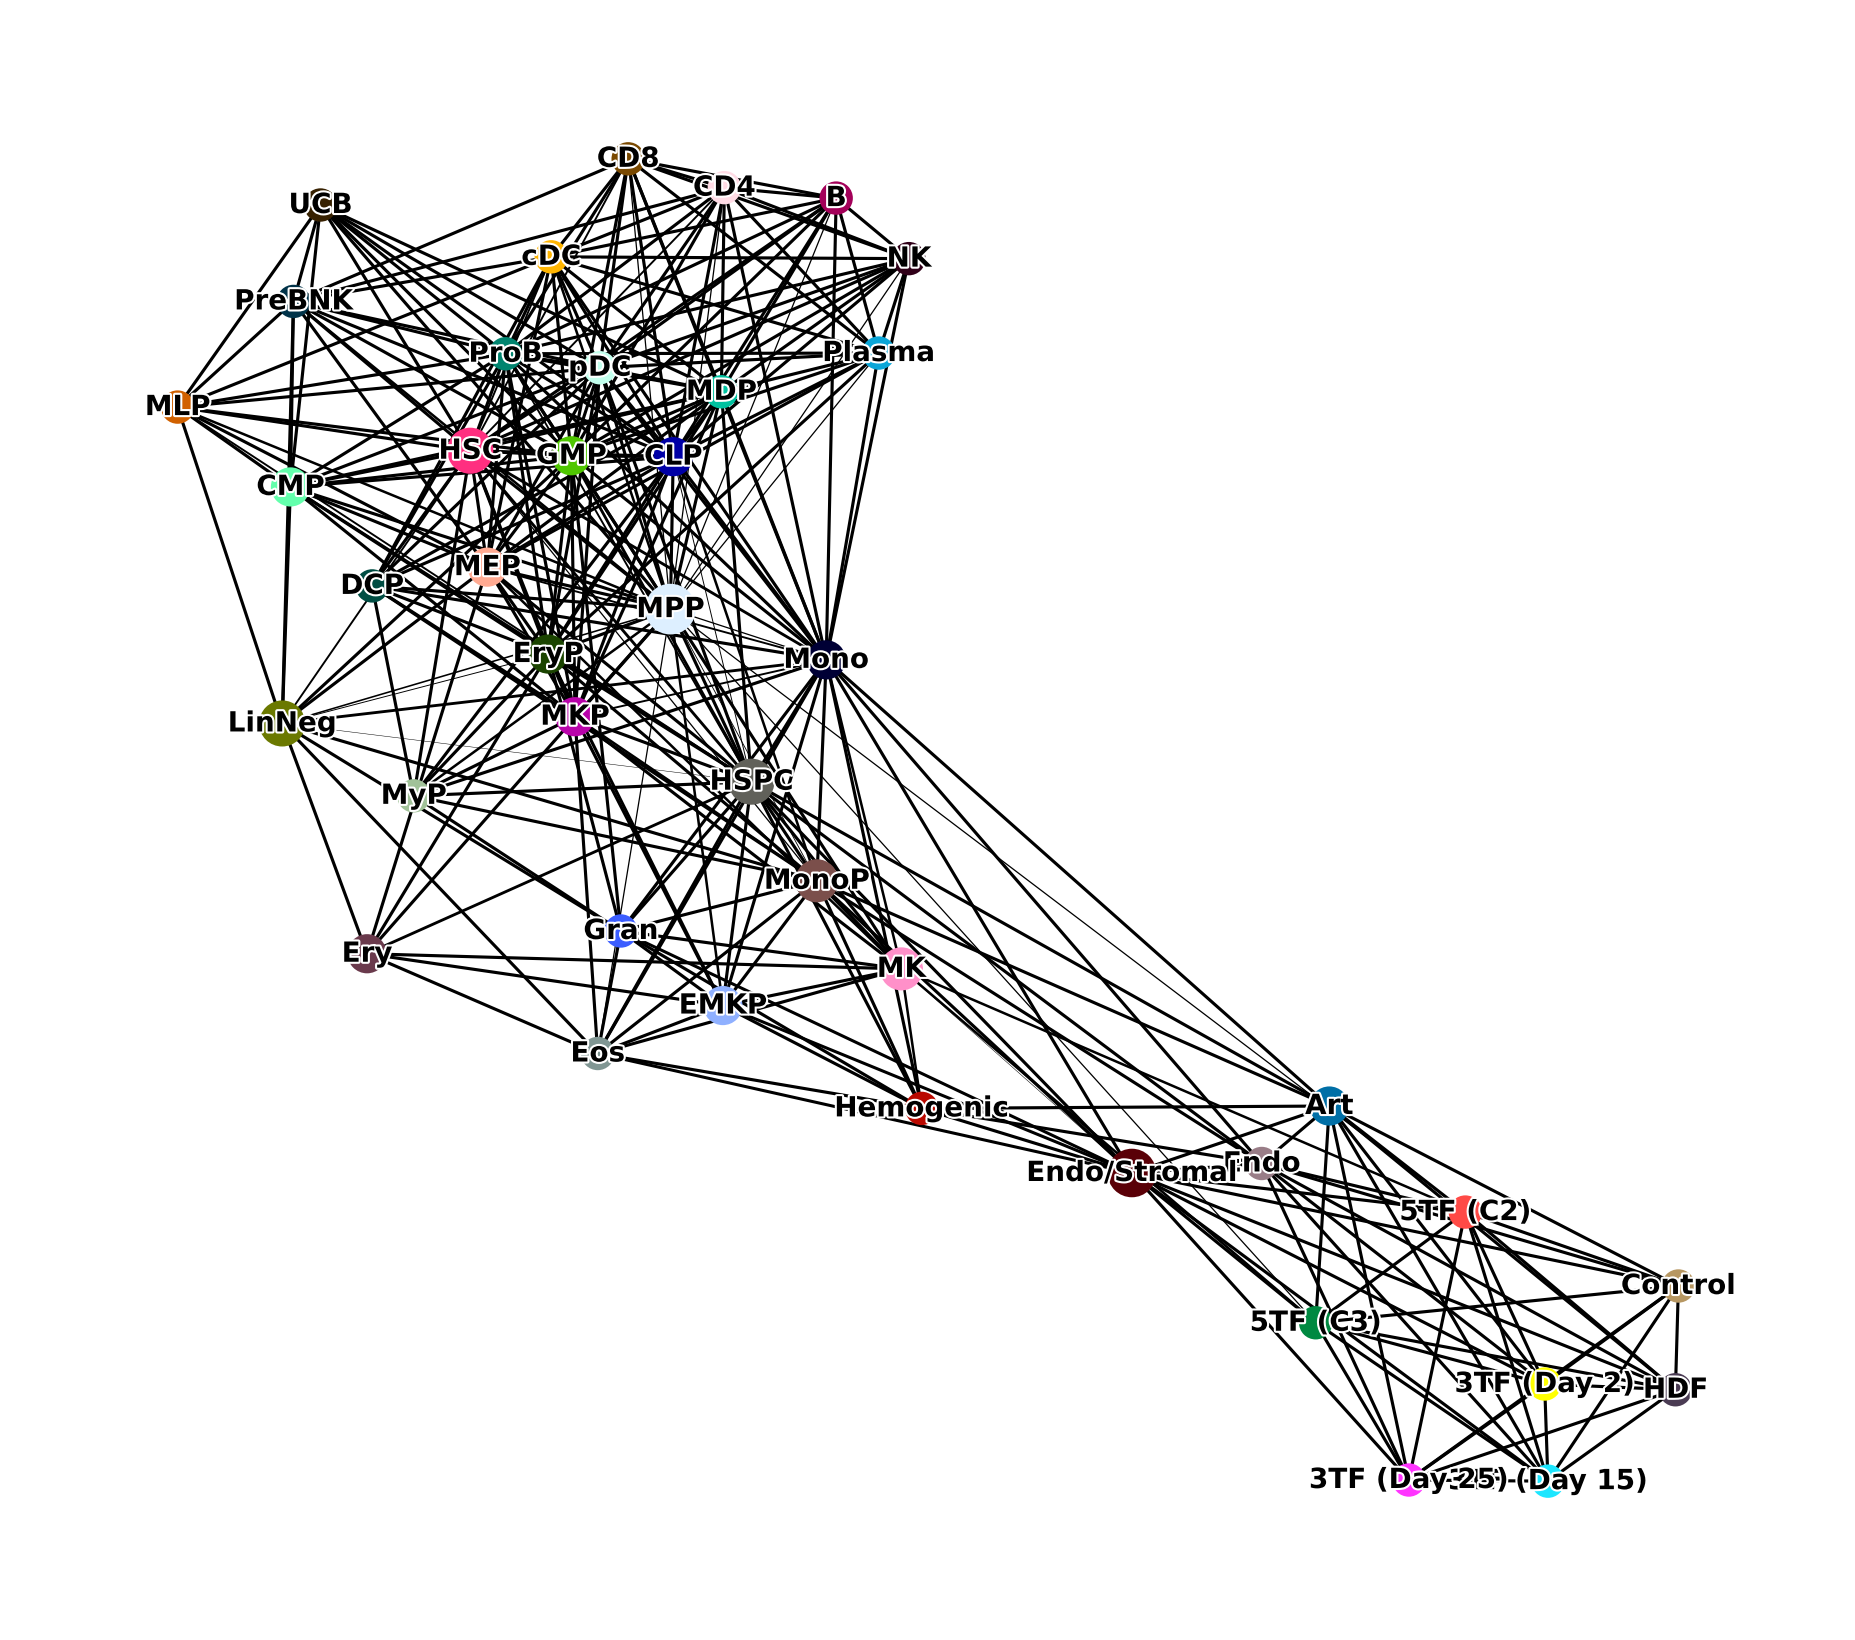

CPU times: user 713 ms, sys: 136 ms, total: 849 ms
Wall time: 1.32 s


In [22]:
%%time
n_neighbors = 15
paga_group_column = "label"
n_pcs = 50

rsc.pp.neighbors(
    embed, 
    n_pcs=n_pcs, 
    n_neighbors=n_neighbors,
)

# plot the embedding
sc.tl.paga(embed, groups=paga_group_column)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 10, 10
sc.pl.paga(
    embed, 
    fontoutline=1.5, 
    edge_width_scale=0.15,  
    frameon=False,          
)

embed.obsm['X_paga'] = get_init_pos_from_paga(embed)

In [23]:
%%time
X = embed.obsm['X_pca']
print(f"{X.shape=}")

dists = pairwise_distances(X, metric='euclidean')
print(f"{dists.shape=}")

df = pd.DataFrame(
    dists, 
    index=embed.obs['label'].values,
    columns=embed.obs['label'].values,
)

df = (df - df.values.min()) / (df.values.max() - df.values.min())

df.head()

X.shape=(74, 23)
dists.shape=(74, 74)
CPU times: user 2.69 ms, sys: 0 ns, total: 2.69 ms
Wall time: 2.72 ms


,5TF (C2),5TF (C3),Control,3TF (Day 2),3TF (Day 15),3TF (Day 25),HDF,UCB,CMP,GMP,...,Mono,Gran,CLP,DCP,EryP,MPP,HSC,MKP,MonoP,MyP
5TF (C2),0.000000,0.076000,0.078405,0.398875,0.383936,0.379892,0.398319,0.740630,0.679901,0.699821,...,0.558986,0.597874,1.000000,0.907450,0.806189,0.857057,0.819714,0.793033,0.875386,0.858446
5TF (C3),0.076000,0.000000,0.112670,0.357783,0.343745,0.338655,0.360614,0.702933,0.660392,0.681380,...,0.560800,0.602282,0.963186,0.878990,0.790647,0.830300,0.791906,0.777481,0.851119,0.833992
Control,0.078405,0.112670,0.000000,0.371829,0.361646,0.358956,0.369908,0.715233,0.649853,0.669590,...,0.511032,0.554201,0.973104,0.879202,0.780455,0.828143,0.791233,0.768427,0.846963,0.829585
3TF (Day 2),0.398875,0.357783,0.371829,0.000000,0.050519,0.058832,0.085114,0.533037,0.560562,0.580350,...,0.509731,0.558004,0.801523,0.736369,0.710879,0.698565,0.664946,0.722119,0.720795,0.708034
3TF (Day 15),0.383936,0.343745,0.361646,0.050519,0.000000,0.013008,0.058072,0.558506,0.585036,0.609573,...,0.545239,0.593074,0.839651,0.775617,0.748263,0.737235,0.702564,0.756833,0.760023,0.746892


In [34]:
pdf = df.copy()
pdf = pdf.loc[['5TF (C2)', '5TF (C3)']].T
pdf = pdf.reset_index(names='target_type')
pdf['dataset'] = adata.obs['batch'].values
pdf = pdf[pdf['dataset'] != 'Our data']
pdf = pd.melt(pdf, id_vars=['target_type', 'dataset'])
pdf['target_type'] = pdf['target_type'].astype(str)
pdf['dataset'] = pdf['dataset'].astype(str)
pdf['variable'] = pdf['variable'].astype(str)
pdf

,target_type,dataset,variable,value
0,3TF (Day 2),Gomes 2018,5TF (C2),0.398875
1,3TF (Day 15),Gomes 2018,5TF (C2),0.383936
2,3TF (Day 25),Gomes 2018,5TF (C2),0.379892
3,HDF,Gomes 2018,5TF (C2),0.398319
4,UCB,Gomes 2018,5TF (C2),0.740630
...,...,...,...,...
137,MPP,Setty 2019,5TF (C3),0.830300
138,HSC,Setty 2019,5TF (C3),0.791906
139,MKP,Setty 2019,5TF (C3),0.777481
140,MonoP,Setty 2019,5TF (C3),0.851119


In [35]:
pdf = pdf[pdf['dataset'] == 'Gomes 2018']

In [36]:

pdf['target_type'] = pdf['target_type'].str.replace(r'Day (\d+)', r'd\1', regex=True)

pdf.head()

/tmp/ipykernel_3030717/3401991684.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf['target_type'] = pdf['target_type'].str.replace(r'Day (\d+)', r'd\1', regex=True)


,target_type,dataset,variable,value
0,3TF (d2),Gomes 2018,5TF (C2),0.398875
1,3TF (d15),Gomes 2018,5TF (C2),0.383936
2,3TF (d25),Gomes 2018,5TF (C2),0.379892
3,HDF,Gomes 2018,5TF (C2),0.398319
4,UCB,Gomes 2018,5TF (C2),0.740630


Gomes 2018 10 5


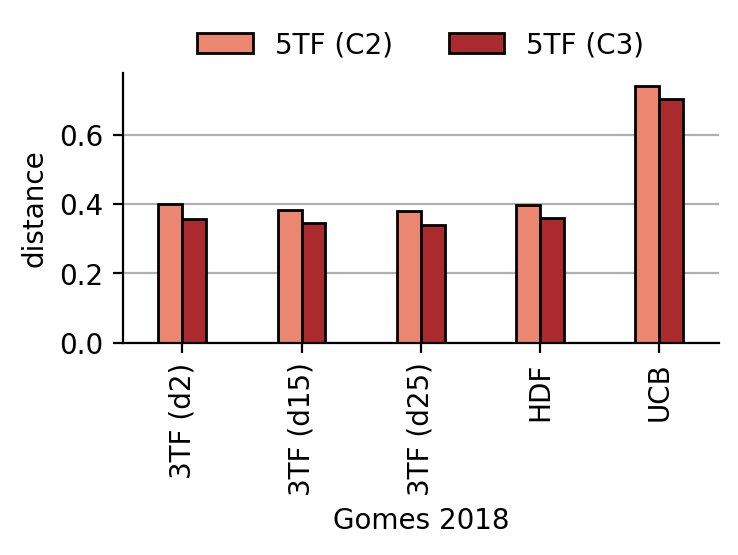

In [45]:
for dataname, group in pdf.groupby('dataset', observed=True):
    print(dataname, len(group), group['target_type'].nunique())

    x_length = group['target_type'].nunique()

    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = x_length / 1.3, 1.75

    sns.barplot(
        data=group,
        x='target_type',
        y='value',
        hue='variable',
        width=0.4,
        palette=['#FF7A5D', '#BF151A'],
        # palette=['C1', 'C2'],
        ec='k',
        zorder=2,
        errorbar=None,
        alpha=1,
    )

    plt.xticks(rotation=90)
    plt.grid(axis='y', zorder=0)
    plt.xlabel(dataname)
    plt.ylabel('distance')
    sns.move_legend(
        plt.gca(),
        loc='upper center',
        title="",
        frameon=False,
        ncols=2,
        bbox_to_anchor=(0.5, 1.25),
    )
    sns.despine()
    plt.show()
    
    break
    # break


In [16]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [20]:
%%time
X = adata[:, adata.var['filter_pass']].X
# X = adata.obsm['X_pca'][:, 0:7]
print(f"{X.shape=}")

dists = pairwise_distances(X, metric='euclidean')
print(f"{dists.shape=}")

df = pd.DataFrame(
    dists.get(), 
    index=pd.MultiIndex.from_frame(adata.obs),
    columns=pd.MultiIndex.from_frame(adata.obs),
)

df.head()

X.shape=(74, 15022)
dists.shape=(74, 74)
CPU times: user 9.17 ms, sys: 1.93 ms, total: 11.1 ms
Wall time: 10.7 ms


,,,cell_type,C2,C3,Control,DAY2,DAY15,DAY25,HDF,UCB,CMP,GMP,...,Mono,Gran,common lymphoid progenitor,dendtritic progenitor,erythroid progenitor,hematopoietic multipotent progenitor,hematopoietic stem cell,megakaryocyte progenitor,monocyte progenitor,myeloid progenitor
,,,batch,Our data,Our data,Our data,Gomes 2018,Gomes 2018,Gomes 2018,Gomes 2018,Gomes 2018,Pellin 2019,Pellin 2019,...,Ng 2024,Ng 2024,Setty 2019,Setty 2019,Setty 2019,Setty 2019,Setty 2019,Setty 2019,Setty 2019,Setty 2019
,,,label,5TF (C2),5TF (C3),Control,3TF (Day 2),3TF (Day 15),3TF (Day 25),HDF,UCB,CMP,GMP,...,Mono,Gran,CLP,DCP,EryP,MPP,HSC,MKP,MonoP,MyP
,,,group,data,data,data,atlas,atlas,atlas,atlas,atlas,atlas,atlas,...,atlas,atlas,atlas,atlas,atlas,atlas,atlas,atlas,atlas,atlas
cell_type,batch,label,group,,,,,,,,,,,,,,,,,,,,,
C2,Our data,5TF (C2),data,0.000000,14.163191,23.137878,45.165025,42.703107,42.950821,46.150924,56.737294,41.345736,41.867989,...,44.704740,45.471507,62.043328,58.855490,57.820005,58.060882,58.582598,58.445341,57.015406,57.819282
C3,Our data,5TF (C3),data,14.163191,0.000000,26.545302,41.732651,40.594796,40.107082,43.851219,54.320658,42.964462,43.454347,...,45.131290,46.078374,61.288120,59.148924,58.048269,57.867326,57.999727,58.583650,57.441158,57.965784
Control,Our data,Control,data,23.137878,26.545302,0.000000,44.442990,42.899497,43.850406,42.839598,56.241125,41.876793,41.984463,...,44.171901,45.117038,62.299668,59.445639,58.744383,58.612932,59.168968,58.909551,57.730727,58.179791
DAY2,Gomes 2018,3TF (Day 2),atlas,45.165025,41.732651,44.442990,0.000000,22.330440,22.437270,26.452408,46.793183,48.255815,48.391764,...,48.479490,48.980891,63.465008,62.518974,61.289089,60.936739,60.595388,61.633298,61.439467,61.409569
DAY15,Gomes 2018,3TF (Day 15),atlas,42.703107,40.594796,42.899497,22.330440,0.000000,16.750372,26.317201,47.056487,47.164222,47.588632,...,48.576078,49.330943,63.410970,62.647349,61.490984,61.018811,60.676673,61.781203,61.272092,61.459778


In [ ]:
target = ['C2', 'C3', 'Control']

for dataset in adata.obs['batch'].unique():
    if dataset == 'Our data':
        continue
    print(dataset)

    mask = df.index.get_level_values('batch').isin([dataset])
    df_selected = df[mask][target]
    print(f"{df_selected.shape=}")

    df_selected.index = df_selected.index.get_level_values('label').astype(str)
    df_selected.columns = df_selected.columns.get_level_values('label').astype(str)

    df_selected = df_selected.groupby(df_selected.index.name)[['5TF (C2)', '5TF (C3)', 'Control']].mean()

    print(df_selected.head())

    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = (1.5, len(df_selected))
    sns.heatmap(
        data=df_selected,
        square=True,
        annot=True,
        cmap='bwr',
        cbar=False,
        # cbar_kws={'shrink': 0.25, 'label': 'distance'},
        lw=0.5,
    )
    ax = plt.gca()
    ax.set_title(dataset)
    ax.set_ylabel("")
    ax.set_xlabel("")
    
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)
    plt.show()
    # break

In [ ]:
break

In [ ]:
# Aggregate by 'cell_type' for both axes
level = "label"
df_agg = df.groupby(level=level, axis=0).mean().groupby(level=level, axis=1).mean()
df_agg = df_agg.sort_index()

print(list(df_agg.index))
print(f"{df_agg.shape=}")
n = df_agg.shape[0]


g = sns.clustermap(
    df_agg,
    square=True,
    # cmap='vlag',
    cmap='bwr',
    linewidth=1,
    figsize=( n / 2.5 ,n / 2.5),
    dendrogram_ratio=(0.0, 0.15),
    annot=True,
    cbar_pos=None,
    row_cluster=False,
    tree_kws={'lw' : 1.25,}
)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")
plt.show()

# Write output

In [ ]:
%%time
outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudobulk/dataset_benchmarks.h5ad"
adata.write(outpath)
adata

In [ ]:
break

In [ ]:
break

# Correlations

In [ ]:
%%time

for dataset, data_dict in data.items():
    X = data_dict['rdata'].to_df()
    A = X.T.corr()
    print(f"{X.shape=} {A.shape=}")

    plt.rcParams['figure.dpi'] = 150

    xy = A.shape[0] / 1.3
    sns.clustermap(
        A,
        annot=True,
        cmap='vlag',
        square=True,
        linewidths=0.5,
        figsize=(xy, xy*0.9),
        cbar_kws={'label': 'Mean Correlation', 'shrink' : 0.35},
        fmt=".2f",
        dendrogram_ratio=(0.2, 0.0),
        tree_kws={'lw' : 1},
        cbar_pos=None,
    )
    plt.title(dataset)
    plt.yticks(rotation=0)
    plt.ylabel('')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()

# Correlations

In [ ]:
def top_percentile_genes_anndata(rdata, sdata, percentile=90):
    """
    Keep only genes in the intersection of rdata and sdata, and restrict to those in the
    top `percentile` mean expression in both datasets.

    rdata, sdata: AnnData objects
    percentile: top percentile to keep (e.g., 90 for top 10%)
    """
    gene_intersection = list(set(rdata.var_names) & set(sdata.var_names))
    X = sdata[:, gene_intersection].X.copy()
    Y = rdata[:, gene_intersection].X.copy()
    
    s_means = np.asarray(X.mean(axis=0)).ravel()
    r_means = np.asarray(Y.mean(axis=0)).ravel()
    s_thresh = np.percentile(s_means, percentile)
    r_thresh = np.percentile(r_means, percentile)
    keep = (s_means >= s_thresh) & (r_means >= r_thresh)
    genes_top = np.array(gene_intersection)[keep]
    return genes_top, X[:, keep], Y[:, keep]

_, X, Y = top_percentile_genes_anndata(rdata, sdata, percentile=25)

In [ ]:
%%time
threshold = 25

results = []

for dataset, data_dict in data.items():
    rdata = data_dict['rdata']

    _, X, Y = top_percentile_genes_anndata(rdata, sdata, percentile=threshold)

    # Pairwise correlation matrix (n, k)
    dist = cdist(X, Y, metric='correlation')
    corr = 1 - dist

    # Get obs_names
    s_obs = sdata.obs_names if hasattr(sdata, 'obs_names') else range(X.shape[0])
    r_obs = rdata.obs_names if hasattr(rdata, 'obs_names') else range(Y.shape[0])

    # Build long-form DataFrame
    df = pd.DataFrame(
        corr,
        index=s_obs,
        columns=r_obs
    ).reset_index().melt(
        id_vars='index',
        var_name='r_obs',
        value_name='correlation'
    ).rename(columns={'index': 's_obs'})
    df['dataset'] = dataset

    results.append(df)

results = pd.concat(results, ignore_index=True)
print(results.head().to_string(index=False))

In [ ]:
plt.rcParams['figure.dpi'] = 220
plt.rcParams['figure.figsize'] = 4, 3

sns.boxplot(
    data=results,
    x='dataset',
    y='correlation',
    hue='s_obs',
    flierprops={'markersize' : 2},
    capprops={'lw' : 0},
    linecolor='k',
)

plt.title("correlation over all benchmarks")
plt.ylabel("correlation")
plt.xlabel("")
plt.grid(axis='y')
sns.move_legend(
    plt.gca(),
    title="",
    loc="center right",
    bbox_to_anchor=(1.3, 0.5),
)
sns.despine()
plt.xticks(rotation=90)

In [ ]:
pdf = results.copy()

keep = [
    'DAY2', 'DAY15', 'DAY25', 'HDF', 'UCB', 'CMP', 'GMP', 'HSC',
    'MPP',  'Ery1', 'Ery2', 'HSPC', 'MPP1', 'MPP2', 'Mk1',
    'Mk2', 'Refined.HSC', 'EryP', 'CLP', 'MDP', 'MKP', 'LMPP', 
    'Strom1', 'Strom2', 'Strom3', 'Strom4', 'Venous', 'Endo', 'Art1',
    'Art2', 'Hemogenic', 'HSPC1', 'HSPC2', 'HSPC3', 'EMK Pro1', 'Eos',
    'EMK Pro2', 'Mega', 'Mye Pro1', 'Mye Pro2', 'Gran'
]

pdf = pdf[pdf['r_obs'].isin(keep)]

pdf = pd.pivot_table(
    pdf, 
    index='s_obs',
    columns=['dataset', 'r_obs'],
    values='correlation'
)

print(f"{pdf.shape=}")

pdf = pdf.apply(zscore, axis=0, nan_policy='omit')

plt.rcParams['figure.dpi'] = 300

sns.clustermap(
    pdf,
    cmap='vlag',
    figsize=(10, 5),
    lw=0.25,
    cbar_pos=None,
    row_cluster=False,
    xticklabels=True,
    dendrogram_ratio=(0, 0.3),
    tree_kws={'lw' : 0.5,},
    annot=True,
    fmt=".2f",
    annot_kws={'fontsize' : 5},
)

plt.yticks(rotation=0)
plt.ylabel('')
plt.xlabel('')

# Gomes

In [ ]:
pdf = results.copy()

keep = [
   'Gomes 2018'
]

pdf = pdf[pdf['dataset'].isin(keep)]
print(pdf['r_obs'].unique())

plt.rcParams['figure.dpi'] = 220
plt.rcParams['figure.figsize'] = 5, 3.5

pdf = pd.pivot_table(
    pdf, 
    index='s_obs',
    columns='r_obs',
    values='correlation'
)

pdf = pdf[['DAY2', 'DAY15', 'DAY25']]
# pdf = pdf[['HDF', 'UCB']]

sns.heatmap(
    pdf, square=True,
    annot=True,
    fmt=".2f",
    cmap='cividis',
    # cmap = LinearSegmentedColormap.from_list("", ['w', 'lightgrey', 'coral', 'r']),
    robust=True,
    lw=1,
    cbar_kws={'shrink' : 0.6, 'label':'correlation'}
)

plt.yticks(rotation=0)
plt.xlabel("Cell Type (Gomes 2018)")
plt.ylabel("")

# Ng et al. 2024

> **Citation:**  
> Ng, E. S., et al. "Long-term engrafting multilineage hematopoietic cells differentiated from human induced pluripotent stem cells." *Nature Biotechnology*, pp. 1–14, Sep. 2024. [doi:10.1038/s41587-024-02360-7](https://doi.org/10.1038/s41587-024-02360-7)

---

## Data Description

**ine.ident**  
- **rm**: RM TOM iPS cells, constitutively expressing a tdTOMATO transgene from the GAPDH locus; derived from human foreskin fibroblasts.
- **pb**: PB1.1 (male), PB10.5 (male), and PB5.1 (female) iPS cells reprogrammed from peripheral blood of healthy volunteers using Sendai virus (POU5F1, SOX2, KLF4, MYC2).

**fract.ident**  
- **sn**: Isolated single cells.
- **swb**: Swirling embryoid bodies.


In [ ]:
# pdf = results.copy()

# keep = [
#    'Ng 2024'
# ]

# pdf = pdf[pdf['dataset'].isin(keep)]
# print(pdf['r_obs'].unique())

# pdf['r_obs_agg'] = pdf['r_obs'].str.replace(r'\d+$', '', regex=True)
# print(pdf['r_obs_agg'].unique())

# for target in ['Strom', 'Venous', 'Endo', 'Art', 'Hemogenic', 'HSPC', 'Mega',]:

#     plt.rcParams['figure.dpi'] = 220
#     plt.rcParams['figure.figsize'] = 2, 2.25
    
#     sns.barplot(
#         data=pdf[pdf['r_obs_agg'] == target],
#         x='s_obs',
#         y='correlation',
#         hue='s_obs',
#         errorbar=None,
#         ec='k',
#         width=0.6,
#         zorder=5
#     )
#     plt.xlabel("")
#     plt.title(target)
#     sns.despine()
#     plt.grid(axis='y')
#     plt.show()


In [ ]:
# pdf = results.copy()

# keep = [
#    'Ng 2024'
# ]

# pdf = pdf[pdf['dataset'].isin(keep)]
# print(pdf['r_obs'].unique())

# pdf['r_obs_agg'] = pdf['r_obs'].str.replace(r'\d+$', '', regex=True)
# print(pdf['r_obs_agg'].unique())

# pdf = pd.pivot_table(
#     pdf, 
#     index='s_obs',
#     columns='r_obs_agg',
#     values='correlation',
#     aggfunc='mean',
# )

# pdf = pdf[['Strom', 'Venous', 'Endo', 'Art', 'Hemogenic', 'HSPC', 'Mega', 'Mono']]

# print(f"{pdf.shape=}")

# plt.rcParams['figure.dpi'] = 220
# plt.rcParams['figure.figsize'] = 10, 3.5

# sns.heatmap(
#     pdf, square=True,
#     annot=True,
#     fmt=".2f",
#     cmap='cividis',
#     robust=True,
#     lw=1,
#     cbar_kws={'shrink' : 0.6, 'label':'correlation'}
# )

# plt.yticks(rotation=0)
# plt.xlabel("Cell Type (Ng 2024)")
# plt.ylabel("")

In [ ]:
pdf = results.copy()

keep = [
   'Ng 2024'
]

pdf = pdf[pdf['dataset'].isin(keep)]
print(pdf['r_obs'].unique())

plt.rcParams['figure.dpi'] = 220
plt.rcParams['figure.figsize'] = 13, 3.5

pdf = pd.pivot_table(
    pdf, 
    index='s_obs',
    columns='r_obs',
    values='correlation'
)

sns.heatmap(
    pdf, square=True,
    annot=True,
    fmt=".2f",
    cmap='cividis',
    # cmap = LinearSegmentedColormap.from_list("", ['w', 'lightgrey', 'coral', 'r']),
    robust=True,
    lw=1,
    cbar_kws={'shrink' : 0.6, 'label':'correlation'}
)


plt.yticks(rotation=0)
plt.xlabel("Cell Type (Ng 2024)")
plt.ylabel("")

In [ ]:
pdf = results.copy()

keep = [
   'Ng 2024'
]

plt.rcParams['figure.dpi'] = 220

pdf = pdf[pdf['dataset'].isin(keep)]
pdf['r_obs_agg'] = pdf['r_obs'].str.replace(r'\d+$', '', regex=True)

pdf = pdf.groupby(['s_obs', 'r_obs_agg'])['correlation'].mean().reset_index()

# Optional: sort r_obs_agg for clarity
order = sorted(pdf['r_obs_agg'].unique())

g = sns.catplot(
    data=pdf,
    x='correlation',
    y='r_obs_agg',
    col='s_obs',
    kind='strip',      # 'strip' or 'box' for mean/dispersion
    order=order,
    height=3,
    aspect=0.5,
    hue='correlation',  
    palette='Reds',
    edgecolor='k',
    linewidth=1,
    legend=False,
)

g.set_axis_labels("correlation", "Ng 2024")
g.set_titles("{col_name}")
for ax in g.axes.flatten():
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xlim(pdf['correlation'].min()-0.05, pdf['correlation'].max()+0.05)

plt.tight_layout()
plt.show()



In [ ]:
# %%time
# bdata = data['Ng 2024']['adata']
# gene_intersection = list(set(bdata.var_names) & set(sdata.var_names))

# bdata = bdata[:, gene_intersection].copy()
# rsc.get.anndata_to_GPU(bdata)
# rsc.pp.normalize_total(bdata, target_sum=1e4)
# rsc.pp.log1p(bdata)
# rsc.get.anndata_to_CPU(bdata)
# bdata

In [ ]:
# for group_name, group in results.groupby('dataset'):
#     # print(group.to_string(index=False))

#     n_groups = group['r_obs'].nunique()

#     g = sns.catplot(
#         data=group, 
#         x="correlation",
#         y="r_obs", 
#         col="s_obs",
#         kind="strip", 
#         height=n_groups/2.5, 
#         aspect=.6,
#         size=n_groups,
#         edgecolor="black",  # <-- edge color for points
#         linewidth=n_groups/7,        # <-- edge line width
#     )
#     g.set_axis_labels("correaltion", group_name)
#     g.set_titles("{col_name}")
#     for ax in g.axes.flat:
#         ax.grid(axis='y', linestyle='--', alpha=0.5)

#     plt.tight_layout()
#     plt.show()
#     # break

In [ ]:
# for group_name, group in results.groupby('dataset'):
#     # print(group.to_string(index=False))

#     n_groups = group['r_obs'].nunique()

#     g = sns.catplot(
#         data=group, 
#         x="correlation",
#         y="s_obs", 
#         col="r_obs",
#         kind="strip", 
#         height=n_groups/2.5, 
#         aspect=.6,
#         size=n_groups,
#         edgecolor="black",  # <-- edge color for points
#         linewidth=n_groups/7,        # <-- edge line width
#     )
#     g.set_axis_labels("correaltion", group_name)
#     g.set_titles("{col_name}")
#     for ax in g.axes.flat:
#         ax.grid(axis='y', linestyle='--', alpha=0.5)

#     plt.tight_layout()
#     plt.show()
#     # break

# ElasticNet

In [ ]:
%%time
def fit_elasticnet_deconvolution(
    rdata, sdata,
    alpha=0.1,
    l1_ratio=1.0,
    fit_intercept=False,
    norm_weights=True,
    max_iter=1000
):
    """
    Fit ElasticNet models to deconvolve each sample in sdata using rdata as reference.

    Returns:
        weights_df: DataFrame [cells x ref_cell_types] of weights
        errors: list of MSEs for each cell
    """
    # Reference matrix and metadata
    R = rdata.X.toarray() if hasattr(rdata.X, "toarray") else np.array(rdata.X)
    ref_cell_types = rdata.obs['cell_type'].tolist()
    # Target matrix
    A = sdata.X.toarray() if hasattr(sdata.X, "toarray") else np.array(sdata.X)
    target_names = sdata.obs_names.tolist()

    weights = []
    errors = []

    for i in range(A.shape[0]):
        x = A[i]
        model = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            fit_intercept=fit_intercept,
            max_iter=max_iter
        )
        model.fit(R.T, x)
        w = model.coef_
        if norm_weights:
            w = w / np.sum(np.abs(w))
        weights.append(w)
        x_pred = np.dot(R.T, w)
        mse = np.mean((x - x_pred) ** 2)
        errors.append(mse)

    weights_df = pd.DataFrame(weights, columns=ref_cell_types, index=target_names)
    return weights_df, errors

# study error on  Gomes

In [ ]:
rdata = data['Gomes 2018']['rdata']
gene_intersection = list(set(rdata.var_names) & set(sdata.var_names))

results = []
steps = 10

for a in np.linspace(0.01, 0.5, steps):
    wdf, e = fit_elasticnet_deconvolution(
        rdata[:, gene_intersection].copy(), 
        sdata[:, gene_intersection].copy(), 
        alpha=a,
        l1_ratio=0.25,
        fit_intercept=False,
        max_iter=1000
    )
    edf = pd.DataFrame({'error' : e, 'cluster' : wdf.index})
    edf['alpha'] = a
    results.append(edf)

results = pd.concat(results)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sns.lineplot(
    data=results,
    x='alpha',
    y='error',
    hue='cluster',
    marker="o",
    lw=1,
)

plt.ylabel("mean squared error")
plt.xlabel(r"$\alpha$")
plt.grid(axis='y')
sns.move_legend(
    plt.gca(),
    title="",
    loc="center right",
    bbox_to_anchor=(1.6, 0.5),
)
sns.despine()

    

In [ ]:
rdata = data['Gomes 2018']['rdata']
gene_intersection = list(set(rdata.var_names) & set(sdata.var_names))

results = []
steps = 10

for l1 in np.linspace(0.0, 1.0, steps):
    wdf, e = fit_elasticnet_deconvolution(
        rdata[:, gene_intersection].copy(), 
        sdata[:, gene_intersection].copy(), 
        alpha=0.05,
        l1_ratio=l1,
        fit_intercept=False,
        max_iter=1000
    )
    edf = pd.DataFrame({'error' : e, 'cluster' : wdf.index})
    edf['l1'] = l1
    results.append(edf)

results = pd.concat(results)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sns.lineplot(
    data=results,
    x='l1',
    y='error',
    hue='cluster',
    marker="o",
    lw=1,
)

plt.ylabel("mean squared error")
plt.xlabel(r"L1 Ratio")
plt.grid(axis='y')
sns.move_legend(
    plt.gca(),
    title="",
    loc="center right",
    bbox_to_anchor=(1.6, 0.5),
)
sns.despine()

In [ ]:
%%time

errors = []
threshold = 0.5

for dataset, data_dict in data.items():
    rdata = data_dict['rdata']

    gene_intersection, _, _ = top_percentile_genes_anndata(rdata, sdata, percentile=threshold)

    wdf, e = fit_elasticnet_deconvolution(
        rdata[:, gene_intersection].copy(), 
        sdata[:, gene_intersection].copy(), 
        alpha=0.01,
        l1_ratio=0.95,
        fit_intercept=False,
        max_iter=1000
    )

    plt.rcParams['figure.dpi'] = 150
    plt.rcParams['figure.figsize'] = wdf.shape[1] * 0.9, 3.5

    sns.heatmap(
        wdf,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        linewidths=0.5,
        linecolor='w',
        cbar_kws={'label': 'wieght', 'shrink' : 0.6},
    )
    
    plt.title(dataset)
    plt.xlabel("")
    plt.ylabel("")
    plt.yticks(rotation=0)
    plt.show()

    # save the error vector
    edf = pd.DataFrame({'error' : e, 'cluster' : wdf.index})
    edf['dataset'] = dataset
    errors.append(edf)


errors = pd.concat(errors)
errors.head()

# Ng 2024

In [ ]:
rdata = data['Ng 2024']['rdata']

threshold = 50 # gene expression percentile
alpha = 0.01
l1_ratio = 0.95

gene_intersection, _, _ = top_percentile_genes_anndata(rdata, sdata, percentile=threshold)

wdf, e = fit_elasticnet_deconvolution(
    rdata[:, gene_intersection].copy(), 
    sdata[:, gene_intersection].copy(), 
    alpha=alpha,
    l1_ratio=l1_ratio,
    fit_intercept=False,
    max_iter=1000
)

print(e)
wdf = wdf.reset_index()
wdf = pd.melt(wdf, id_vars='index')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 2.5

sns.scatterplot(
    data=wdf, 
    y='index',
    x='variable',
    size='value',
    hue='value',
    palette=LinearSegmentedColormap.from_list("", ['w', 'r']),
    # palette='Reds',
    sizes=(0, 150),
    zorder=5,
    ec='k',
    lw=1,
)

sns.move_legend(
    plt.gca(),
    title="",
    loc="center right",
    bbox_to_anchor=(1.3, 0.5),
)

plt.ylabel("")
plt.xlabel("")
plt.margins(x=0.05, y=0.1)
plt.xticks(rotation=90)
plt.grid(True)

In [ ]:
rdata = data['Ng 2024']['rdata']
rdata.obs['cell_group'] = rdata.obs['cell_type'].str.replace(r'\d+$', '', regex=True)

rdata = sc.get.aggregate(
    rdata,
    by='cell_group',
    func='mean',
)
    
rdata.X = rdata.layers['mean']
rdata.obs['cell_type'] = rdata.obs['cell_group']
rsc.get.anndata_to_GPU(rdata)
rsc.pp.normalize_total(rdata, target_sum=1e4)
rsc.pp.log1p(rdata)
rsc.get.anndata_to_CPU(rdata)


threshold = 5 # gene expression percentile
alpha = 0.01
l1_ratio = 0.95

gene_intersection, _, _ = top_percentile_genes_anndata(rdata, sdata, percentile=threshold)

wdf, e = fit_elasticnet_deconvolution(
    rdata[:, gene_intersection].copy(), 
    sdata[:, gene_intersection].copy(), 
    alpha=alpha,
    l1_ratio=l1_ratio,
    fit_intercept=False,
    max_iter=1000
)

print(e)
wdf = wdf.reset_index()
wdf = pd.melt(wdf, id_vars='index')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 2.5

sns.scatterplot(
    data=wdf, 
    y='index',
    x='variable',
    size='value',
    hue='value',
    palette=LinearSegmentedColormap.from_list("", ['w', 'r']),
    # palette='Reds',
    sizes=(0, 150),
    zorder=5,
    ec='k',
    lw=1,
)

sns.move_legend(
    plt.gca(),
    title="",
    loc="center right",
    bbox_to_anchor=(1.3, 0.5),
)

plt.ylabel("")
plt.xlabel("")
plt.margins(x=0.05, y=0.1)
plt.xticks(rotation=90)
plt.grid(True)

# Error

In [ ]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 5, 3.5

sns.barplot(
    data=errors,
    x='dataset',
    y='error',
    hue='cluster',
    ec='k',
    zorder=4,
)

plt.ylabel("mean squared error")
plt.xlabel("")
plt.grid(axis='y')
sns.move_legend(
    plt.gca(),
    title="",
    loc="center right",
    bbox_to_anchor=(1.3, 0.5),
)
sns.despine()
plt.xticks(rotation=90)

In [ ]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 5, 3.5

sns.barplot(
    data=errors,
    x='cluster',
    y='error',
    hue='dataset',
    ec='k',
    zorder=4,
    palette='Spectral',
)

plt.ylabel("mean squared error")
plt.xlabel("")
plt.grid(axis='y')
sns.move_legend(
    plt.gca(),
    title="",
    loc="center right",
    bbox_to_anchor=(1.6, 0.5),
)
sns.despine()


In [ ]:
break